In [27]:
from Environment import *
from DDPG import *
from NN_Module import *

import torch
import matplotlib.pyplot as plt
import numpy as np

from loguru import logger

### a simple logger
logger.remove()
logger.add(sys.stderr, level='INFO')

5

In [28]:
env_seed = 5        #10-h  5-h 0-l 1-h 2-l 3-l 4l 7h 8h 9l
episode_num = 100   # the total test episode
step_num = 200      # the longest test step

### create testing environment
injection_bus = np.array([18, 21, 30, 45, 53])-1
pp_net = create_56bus()
env = VoltageCtrl_Env(pp_net, injection_bus)
state, topology, senario = env.reset(seed=env_seed)
topology = torch.cuda.FloatTensor(topology).unsqueeze(0)
# pf_res_plotly(pp_net);

### Some Plot Function

In [29]:
# plot policy
def plot_policy(policy_net, topology):
    fig, axs = plt.subplots(1, 5, figsize=(15,3))
    title = ['Bus 18', 'Bus 21', 'Bus 30', 'Bus 45', 'Bus 53']
    for i in range(5):
        axs[i].clear()
        # plot policy
        N = 40
        s_array = np.zeros(N,)
        
        a_array_baseline = np.zeros(N,)
        a_array = np.zeros(N,)
        
        for j in range(N):
            state = torch.tensor([[0.80+0.01*j]])
            s_array[j] = state

            action_baseline = (np.maximum(state.cpu()-1.05, 0)-np.maximum(0.95-state.cpu(), 0)).reshape((1,))
        
            action = policy_net[i](state, topology)
            action = action.detach().cpu().numpy()[0]
            
            a_array_baseline[j] = -action_baseline[0]
            a_array[j] = -action

        axs[i].plot(12*s_array, 2*a_array_baseline, '-.', label = 'Linear')
        axs[i].plot(12*s_array, a_array, label = 'Flexible-DDPG')
        axs[i].set_title(title[i])
        axs[i].legend(loc='lower left')

def plot_safe_net(net):
    fig, axs = plt.subplots(1, 5, figsize=(15,3))
    title = ['Bus 18', 'Bus 21', 'Bus 30', 'Bus 45', 'Bus 53']
    for i in range(agent_num):
        N = 40
        s_array = np.zeros(N,)
        
        a_array_baseline = np.zeros(N,)
        a_array = np.zeros(N,)
        
        for j in range(N):
            state = np.array([0.8+0.01*j])
            s_array[j] = state

            action_baseline = (np.maximum(state-1.05, 0)-np.maximum(0.95-state, 0)).reshape((1,))
        
            action = net[i].get_action([state])
            
            a_array_baseline[j] = -action_baseline[0]
            a_array[j] = -action

        axs[i].plot(12*s_array, 2*a_array_baseline, '-.', label = 'Linear')
        axs[i].plot(12*s_array, a_array, label = 'Stable-DDPG')
        axs[i].legend(loc='lower left')

def plot_x_policy(policy_net, topology):
    fig, axs = plt.subplots()
    for i in range(5):
        # plot policy
        N = 40
        s_array = np.zeros(N,)
        
        a_array_baseline = np.zeros(N,)
        a_array = np.zeros(N,)
        topology = torch.cuda.FloatTensor(env.topology_init * np.random.uniform(0.7,1.3)).unsqueeze(0)
        
        for j in range(N):
            state = torch.tensor([[0.80+0.01*j]])
            s_array[j] = state

            action_baseline = (np.maximum(state.cpu()-1.05, 0)-np.maximum(0.95-state.cpu(), 0)).reshape((1,))
        
            action = policy_net[2](state, topology)
            action = action.detach().cpu().numpy()[0]
            
            a_array_baseline[j] = -action_baseline[0]
            a_array[j] = -action

        axs.plot(12*s_array, a_array_baseline, '-.', label = 'Linear')
        axs.plot(12*s_array, a_array, label = 'Flexible-DDPG')
        axs.legend(loc='lower left')
        plt.pause(0.1)

### Load model

In [67]:
agent_num = 5
agent_policy_net = []
safe_agent_net = []

### load nn model parameter from saved model 
for i in range(agent_num):
    topology_net = TopologyNet(topology_dim=55, output_dim=1, hidden_dim=256)
    policy_net = FlexiblePolicyNet(env=env, topology_net=topology_net, obs_dim=1, action_dim=1, hidden_dim=2048).to(device)
    agent_policy_net.append(policy_net)

for i in range(agent_num):
    policy_net = SafePolicyNetwork(env=env, obs_dim=1, action_dim=1, hidden_dim=100).to(device)
    safe_agent_net.append(policy_net)

for i in range(agent_num):
    #value_net_dict = torch.load(f'check_points/value_net/2023-06-19/Step_200_Seed_12_a{i}.pth')
    policy_net_dict = torch.load(f'check_points/policy_net/2023-07-05/Step_250_Seed_45_a{i}.pth')
    agent_policy_net[i].load_state_dict(policy_net_dict)

for i in range(agent_num):
    #value_net_dict = torch.load(f'D:/Code/Python/StableRL_VoltageCtrl-main/saved_models/2023-06-19/SafeDDPG_value_Step_200_a{i}.pth')
    policy_net_dict = torch.load(f'D:/Code/Python/StableRL_VoltageCtrl-main/saved_models/stable_ddpg/policy_net_checkpoint_a{i}.pth')
    safe_agent_net[i].load_state_dict(policy_net_dict)

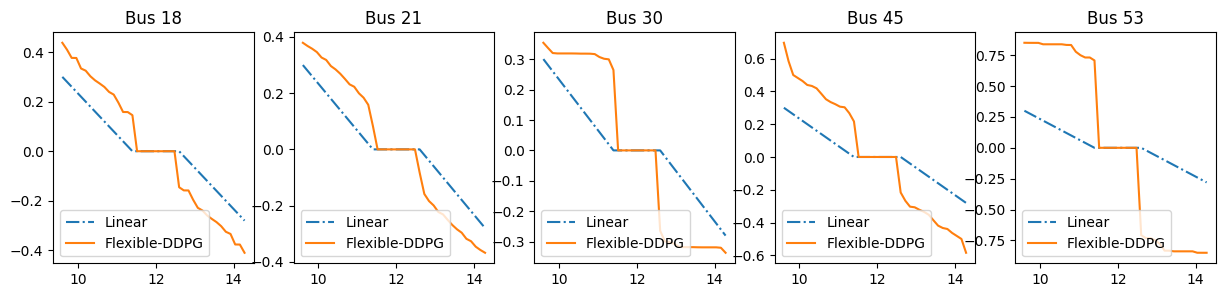

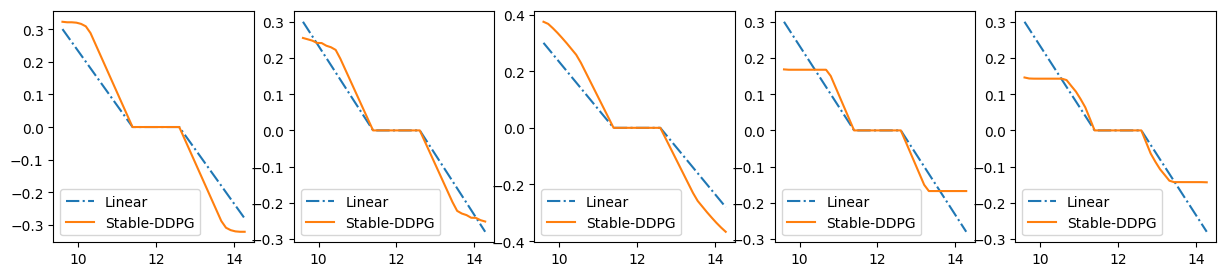

In [68]:
plot_policy(agent_policy_net, topology)
plot_safe_net(safe_agent_net)

### Flexible NN Contoller

In [69]:
### test our controller
voltage = []
q = []
cost = []
success_list = []
fail_list = []
entire_list = []
control_cost = []
reward_list = []

for episode in range(episode_num):
    state, topology, senario = env.reset(seed=episode)
    topology = torch.cuda.FloatTensor(topology).unsqueeze(0)
    last_action = np.zeros((agent_num,1))
    episode_reward = 0
    episode_control = 0
    abnormal_stop = False

    for step in range(step_num):
        action = []
        for i in range(agent_num):
            action_agent = agent_policy_net[i](torch.cuda.FloatTensor(state[i].reshape(1,)).unsqueeze(0), topology)
            action_agent = action_agent.detach().cpu().numpy()[0]
            action.append(action_agent)

        action = last_action - np.asarray(action)
        
        last_action = np.copy(action)
        
        try:
            next_state, reward, done = env.step(action)
        except pp.powerflow.LoadflowNotConverged:
            # logger.error(sys.exc_info())
            logger.error('power flow not converge at epsisode{} step{}', episode, step)
            fail_list.append((episode,step))
            abnormal_stop = True
            break

        if(np.min(next_state) < 0.75 or np.max(next_state) > 1.25): #if voltage violation > 25%, episode ends.
            logger.warning('episode {} step {} exceeds, min_state is {}, max_state is {}', episode, step, np.min(next_state), np.max(next_state))
            fail_list.append((episode,step))
            abnormal_stop = True
            break
        if done:
            success_list.append((episode,step))
            logger.success('stable at {}',success_list[-1])
            break

        voltage.append(state)

        q.append(action)

        state = next_state
        
        episode_reward += reward
        
        cost.append(-reward)
        
        episode_control += LA.norm(action, 2)

    reward_list.append(episode_reward)
    control_cost.append(episode_control)

    if (not done) and (abnormal_stop == False):
        entire_list.append(episode)
        logger.info('Episode {} finish with entire step!', episode)

logger.info('total success epsisode is {}', len(success_list))
logger.info('total fail episode is {}', len(fail_list))
logger.info('number of finished at entire episode is {}', len(entire_list))

2023-07-05 16:34:24.281 | SUCCESS  | __main__:<module>:46 - stable at (0, 8)
2023-07-05 16:34:24.701 | SUCCESS  | __main__:<module>:46 - stable at (1, 8)
2023-07-05 16:34:25.202 | SUCCESS  | __main__:<module>:46 - stable at (2, 12)
2023-07-05 16:34:25.649 | SUCCESS  | __main__:<module>:46 - stable at (3, 11)
2023-07-05 16:34:25.949 | SUCCESS  | __main__:<module>:46 - stable at (4, 7)
2023-07-05 16:34:26.579 | SUCCESS  | __main__:<module>:46 - stable at (5, 17)
2023-07-05 16:34:26.670 | SUCCESS  | __main__:<module>:46 - stable at (6, 1)
2023-07-05 16:34:27.942 | SUCCESS  | __main__:<module>:46 - stable at (7, 34)
2023-07-05 16:34:28.358 | SUCCESS  | __main__:<module>:46 - stable at (8, 10)
2023-07-05 16:34:28.544 | SUCCESS  | __main__:<module>:46 - stable at (9, 4)
2023-07-05 16:34:28.910 | SUCCESS  | __main__:<module>:46 - stable at (10, 9)
2023-07-05 16:34:29.544 | SUCCESS  | __main__:<module>:46 - stable at (11, 15)
2023-07-05 16:34:30.043 | SUCCESS  | __main__:<module>:46 - stable a

In [70]:
success_list = np.array(success_list)
print(np.mean(success_list[:,1]))
print(np.mean(control_cost))


9.41
25.2632167001898


In [53]:
### test our controller
episode_reward = 0
episode_control = 0
voltage = []
q = []
cost = []
success_list = []
fail_list = []
entire_list = []

for episode in range(episode_num):
    state, topology, senario = env.reset_init(seed=episode)
    topology = torch.cuda.FloatTensor(topology).unsqueeze(0)
    last_action = np.zeros((agent_num,1))
    abnormal_stop = False

    for step in range(step_num):
        action = []
        for i in range(agent_num):
            action_agent = agent_policy_net[i](torch.cuda.FloatTensor(state[i].reshape(1,)).unsqueeze(0), topology)
            action_agent = action_agent.detach().cpu().numpy()[0]
            action.append(action_agent)

        action = last_action - 2*np.asarray(action)
        
        last_action = np.copy(action)
        
        try:
            next_state, reward, done = env.step(action)
        except pp.powerflow.LoadflowNotConverged:
            # logger.error(sys.exc_info())
            logger.error('power flow not converge at epsisode{} step{}', episode, step)
            fail_list.append((episode,step))
            abnormal_stop = True
            break

        if(np.min(next_state) < 0.75 or np.max(next_state) > 1.25): #if voltage violation > 25%, episode ends.
            logger.warning('episode {} step {} exceeds, min_state is {}, max_state is {}', episode, step, np.min(next_state), np.max(next_state))
            fail_list.append((episode,step))
            abnormal_stop = True
            break
        if done:
            success_list.append((episode,step))
            logger.success('stable at {}',success_list[-1])
            break

        voltage.append(state)

        q.append(action)

        state = next_state
        
        episode_reward += reward
        
        cost.append(-reward)
        
        episode_control += LA.norm(action, 2)

    if (not done) and (abnormal_stop == False):
        entire_list.append(episode)
        logger.info('Episode {} finish with entire step!', episode)

logger.info('total success epsisode is {}', len(success_list))
logger.info('total fail episode is {}', len(fail_list))
logger.info('number of finished at entire episode is {}', len(entire_list))

2023-07-04 20:50:39.022 | SUCCESS  | __main__:<module>:44 - stable at (0, 10)
2023-07-04 20:50:39.586 | SUCCESS  | __main__:<module>:44 - stable at (1, 13)
2023-07-04 20:50:40.092 | SUCCESS  | __main__:<module>:44 - stable at (2, 11)
2023-07-04 20:50:40.513 | SUCCESS  | __main__:<module>:44 - stable at (3, 10)
2023-07-04 20:50:41.202 | SUCCESS  | __main__:<module>:44 - stable at (4, 17)
2023-07-04 20:50:41.581 | SUCCESS  | __main__:<module>:44 - stable at (5, 7)
2023-07-04 20:50:42.314 | SUCCESS  | __main__:<module>:44 - stable at (6, 19)
2023-07-04 20:50:42.473 | SUCCESS  | __main__:<module>:44 - stable at (7, 3)
2023-07-04 20:50:42.574 | SUCCESS  | __main__:<module>:44 - stable at (8, 1)
2023-07-04 20:50:42.881 | SUCCESS  | __main__:<module>:44 - stable at (9, 7)
2023-07-04 20:50:43.050 | SUCCESS  | __main__:<module>:44 - stable at (10, 3)
2023-07-04 20:50:43.415 | SUCCESS  | __main__:<module>:44 - stable at (11, 7)
2023-07-04 20:50:43.720 | SUCCESS  | __main__:<module>:44 - stable a

In [54]:
success_list = np.array(success_list)
print(np.mean(success_list[:,1]))
print(np.mean(control_cost))

10.22
[173.48828334945674, 49.86316873687228, 299.29973246008467, 56.385648278516186, 14.464317298485316, 456.17414670275053, 2.5753145372625372, 547.9107155637817, 56.8770337590002, 17.955148159889546, 188.0405367698182, 179.181688569758, 110.19429704739979, 189.38912212598956, 48.58446053103942, 19.668187694040707, 2.33293967466858, 453.2450539423646, 22.90943062765482, 134.02507696966518, 42.47220076674993, 35.24726601873608, 65.87600285639901, 78.26370382072601, 15.043701169661494, 4.033509685560893, 31.24850875672363, 214.8358043885758, 24.032780709193215, 59.75844507107013, 0.6324461632739266, 47.395874009752475, 183.55568315630387, 123.82192812515606, 161.46000679837826, 95.2942807412288, 374.37997407430544, 341.40677789833217, 53.657909369128234, 499.93264526513036, 8.197979467520266, 21.078037447377667, 11.298525256948512, 0.22668961997823947, 2.0025108958312154, 203.72726584931365, 252.6326703649687, 42.284379328269864, 39.68559254572713, 33.06635821317073, 8.94383907845113, 

### baseline

In [55]:
### test the base line controller
num_agent = 5
voltage = []
q = []
cost = []
base_succ_list = []
base_fail_list = []
base_entire_list = []
base_control_cost = []
base_reward_list = []

for episode in range(episode_num):
    state, topology, senario = env.reset(seed=episode)
    topology = torch.cuda.FloatTensor(topology).unsqueeze(0)
    last_action = np.zeros((agent_num,1))
    episode_reward = 0
    episode_control = 0
    abnormal_stop = False

    for step in range(step_num):
        state1 = np.asarray(state-env.vmax)
        state2 = np.asarray(env.vmin-state)
        d_v = (np.maximum(state1, 0)-np.maximum(state2, 0)).reshape((num_agent,1))
        
        action = (last_action - 10*d_v)
        
        last_action = np.copy(action)
        
        try:
            next_state, reward, done = env.step(action)
        except pp.powerflow.LoadflowNotConverged:
            # logger.error(sys.exc_info())
            logger.error('power flow not converge at epsisode{} step{}', episode, step)
            base_fail_list.append((episode,step))
            abnormal_stop = True
            break

        if(np.min(next_state) < 0.75 or np.max(next_state) > 1.25): #if voltage violation > 25%, episode ends.
            logger.warning('episode {} step {} exceeds, min_state is {}, max_state is {}', episode, step, np.min(next_state), np.max(next_state))
            base_fail_list.append((episode,step))
            abnormal_stop = True
            break
        if done:
            base_succ_list.append((episode,step))
            logger.success('stable at {}',base_succ_list[-1])
            break

        voltage.append(state)

        q.append(action)

        state = next_state
        
        episode_reward += reward
        
        cost.append(-reward)
        
        episode_control += LA.norm(action, 2)

    base_control_cost.append(episode_control)
    base_reward_list.append(episode_reward)
    
    if (not done) and (abnormal_stop == False):
        base_entire_list.append(episode)
        logger.info('Episode {} finish with entire step!', episode)

logger.info('total success epsisode is {}', len(base_succ_list))
logger.info('total fail episode is {}', len(base_fail_list))
logger.info('number of finished at entire episode is {}', len(base_entire_list))

2023-07-04 20:51:41.207 | SUCCESS  | __main__:<module>:45 - stable at (0, 51)
2023-07-04 20:51:41.441 | SUCCESS  | __main__:<module>:45 - stable at (1, 14)
2023-07-04 20:51:42.301 | SUCCESS  | __main__:<module>:45 - stable at (2, 62)
2023-07-04 20:51:42.655 | SUCCESS  | __main__:<module>:45 - stable at (3, 24)
2023-07-04 20:51:43.304 | SUCCESS  | __main__:<module>:45 - stable at (4, 48)
2023-07-04 20:51:43.953 | SUCCESS  | __main__:<module>:45 - stable at (5, 48)
2023-07-04 20:51:44.114 | SUCCESS  | __main__:<module>:45 - stable at (6, 10)
2023-07-04 20:51:45.102 | SUCCESS  | __main__:<module>:45 - stable at (7, 72)
2023-07-04 20:51:46.027 | SUCCESS  | __main__:<module>:45 - stable at (8, 70)
2023-07-04 20:51:46.280 | SUCCESS  | __main__:<module>:45 - stable at (9, 17)
2023-07-04 20:51:47.137 | SUCCESS  | __main__:<module>:45 - stable at (10, 62)
2023-07-04 20:51:47.455 | SUCCESS  | __main__:<module>:45 - stable at (11, 22)
2023-07-04 20:51:47.722 | SUCCESS  | __main__:<module>:45 - st

In [56]:
base_succ_list = np.array(base_succ_list)
print(np.mean(base_succ_list[:,1]))
print(base_control_cost)
print(np.mean(base_control_cost))


36.84
[452.515256492284, 52.58536500761019, 599.2942335116403, 65.33194106998053, 222.75026498159968, 613.4037595798535, 5.1592157966503525, 4309.255155373219, 621.6153213831211, 18.241738911926713, 553.8756703231784, 140.14858978015678, 114.60035568633484, 515.22388731165, 97.28088364678842, 23.115074592335073, 179.2394228099275, 3380.4181507476624, 24.127157711792496, 1475.1130922444845, 114.73340727786822, 37.88331574920274, 141.07259521496925, 1037.6819644555019, 58.827224651577886, 5.623644518633571, 588.0995515841454, 328.7655240139889, 23.743694723226774, 889.470137112864, 30.72843987868076, 85.75346488478013, 365.49231056754, 437.31355272917864, 579.6218135584222, 77.66656174860958, 3170.9346409179743, 2887.447439732987, 175.7241265896052, 578.4964797570254, 91.75083668011392, 29.567893019760138, 147.41152951373635, 2.2683590143857453, 51.45642363303733, 277.21657631588283, 2049.0896723430187, 92.29587390225791, 173.06215018396762, 36.06508052390999, 111.65472953851882, 702.064

### Safe DDPG

In [63]:
### test the safe policy net
num_agent = 5
safe_voltage = []
safe_q = []
safe_cost = []
safe_succ_list = []
safe_fail_list = []
safe_entire_list = []
safe_contorl_cost = []
safe_reward_list = []

for episode in range(episode_num):
    state, topology, senario = env.reset(seed=episode)
    topology = torch.cuda.FloatTensor(topology).unsqueeze(0)
    last_action = np.zeros((agent_num,1))
    episode_reward = 0
    episode_control = 0
    abnormal_stop = False

    for step in range(step_num):
        action = []
        for i in range(num_agent):
            action_agent = safe_agent_net[i].get_action(torch.cuda.FloatTensor([state[i]]).float().reshape(1,1))
            action.append(action_agent)
        
        action = last_action - 5*np.asarray(action).reshape((num_agent, 1))
        
        last_action = np.copy(action)
        
        try:
            next_state, reward, done = env.step(action)
        except pp.powerflow.LoadflowNotConverged:
            # logger.error(sys.exc_info())
            logger.error('power flow not converge at epsisode{} step{}', episode, step)
            safe_fail_list.append((episode,step))
            abnormal_stop = True
            break

        if(np.min(next_state) < 0.75 or np.max(next_state) > 1.25): #if voltage violation > 25%, episode ends.
            logger.warning('episode {} step {} exceeds, min_state is {}, max_state is {}', episode, step, np.min(next_state), np.max(next_state))
            safe_fail_list.append((episode,step))
            abnormal_stop = True
            break
        if done:
            safe_succ_list.append((episode,step))
            logger.success('stable at {}',safe_succ_list[-1])
            break
        safe_voltage.append(state)

        safe_q.append(action)

        state = next_state
        
        episode_reward += reward
        
        safe_cost.append(-reward)
        
        episode_control += LA.norm(action, 2)

    safe_contorl_cost.append(episode_control)
    safe_reward_list.append(episode_reward)

    if (not done) and (abnormal_stop == False):
        safe_entire_list.append(episode)
        logger.info('Episode {} finish with entire step!', episode)

logger.info('total success epsisode is {}', len(safe_succ_list))
logger.info('total fail episode is {}', len(safe_fail_list))
logger.info('number of finished at entire episode is {}', len(safe_entire_list))


2023-07-05 10:34:37.389 | SUCCESS  | __main__:<module>:46 - stable at (0, 34)
2023-07-05 10:34:37.615 | SUCCESS  | __main__:<module>:46 - stable at (1, 7)
2023-07-05 10:34:38.688 | SUCCESS  | __main__:<module>:46 - stable at (2, 41)
2023-07-05 10:34:39.038 | SUCCESS  | __main__:<module>:46 - stable at (3, 13)
2023-07-05 10:34:39.729 | SUCCESS  | __main__:<module>:46 - stable at (4, 29)
2023-07-05 10:34:40.546 | SUCCESS  | __main__:<module>:46 - stable at (5, 32)
2023-07-05 10:34:40.596 | SUCCESS  | __main__:<module>:46 - stable at (6, 0)
2023-07-05 10:34:41.801 | SUCCESS  | __main__:<module>:46 - stable at (7, 50)
2023-07-05 10:34:42.936 | SUCCESS  | __main__:<module>:46 - stable at (8, 48)
2023-07-05 10:34:43.214 | SUCCESS  | __main__:<module>:46 - stable at (9, 9)
2023-07-05 10:34:44.375 | SUCCESS  | __main__:<module>:46 - stable at (10, 42)
2023-07-05 10:34:44.761 | SUCCESS  | __main__:<module>:46 - stable at (11, 12)
2023-07-05 10:34:45.060 | SUCCESS  | __main__:<module>:46 - stabl

In [64]:
safe_succ_list = np.array(safe_succ_list)
print(np.mean(safe_succ_list[:,1]))
print(np.mean(safe_contorl_cost))

21.59
69.16895381392612


In [44]:
### test the safe policy net
num_agent = 5
safe_voltage = []
safe_q = []
safe_cost = []
safe_succ_list = []
safe_fail_list = []
safe_entire_list = []
safe_contorl_cost = []
safe_reward_list = []

for episode in range(episode_num):
    state, topology, senario = env.reset(seed=episode)
    topology = torch.cuda.FloatTensor(topology).unsqueeze(0)
    last_action = np.zeros((agent_num,1))
    episode_reward = 0
    episode_control = 0
    abnormal_stop = False

    for step in range(step_num):
        action = []
        for i in range(num_agent):
            action_agent = safe_agent_net[i].get_action(torch.cuda.FloatTensor([state[i]]).float().reshape(1,1))
            action.append(action_agent)
        
        action = last_action - 2*np.asarray(action).reshape((num_agent, 1))
        
        last_action = np.copy(action)
        
        try:
            next_state, reward, done = env.step(action)
        except pp.powerflow.LoadflowNotConverged:
            # logger.error(sys.exc_info())
            logger.error('power flow not converge at epsisode{} step{}', episode, step)
            safe_fail_list.append((episode,step))
            abnormal_stop = True
            break

        if(np.min(next_state) < 0.75 or np.max(next_state) > 1.25): #if voltage violation > 25%, episode ends.
            logger.warning('episode {} step {} exceeds, min_state is {}, max_state is {}', episode, step, np.min(next_state), np.max(next_state))
            safe_fail_list.append((episode,step))
            abnormal_stop = True
            break
        if done:
            safe_succ_list.append((episode,step))
            logger.success('stable at {}',safe_succ_list[-1])
            break
        safe_voltage.append(state)

        safe_q.append(action)

        state = next_state
        
        episode_reward += reward
        
        safe_cost.append(-reward)
        
        episode_control += LA.norm(action, 2)

    safe_contorl_cost.append(episode_control)
    safe_reward_list.append(episode_reward)

    if (not done) and (abnormal_stop == False):
        safe_entire_list.append(episode)
        logger.info('Episode {} finish with entire step!', episode)

logger.info('total success epsisode is {}', len(safe_succ_list))
logger.info('total fail episode is {}', len(safe_fail_list))
logger.info('number of finished at entire episode is {}', len(safe_entire_list))


2023-07-04 19:02:01.097 | SUCCESS  | __main__:<module>:46 - stable at (0, 34)
2023-07-04 19:02:01.308 | SUCCESS  | __main__:<module>:46 - stable at (1, 7)
2023-07-04 19:02:02.377 | SUCCESS  | __main__:<module>:46 - stable at (2, 41)
2023-07-04 19:02:02.747 | SUCCESS  | __main__:<module>:46 - stable at (3, 13)
2023-07-04 19:02:03.500 | SUCCESS  | __main__:<module>:46 - stable at (4, 29)
2023-07-04 19:02:04.341 | SUCCESS  | __main__:<module>:46 - stable at (5, 32)
2023-07-04 19:02:04.380 | SUCCESS  | __main__:<module>:46 - stable at (6, 0)
2023-07-04 19:02:05.844 | SUCCESS  | __main__:<module>:46 - stable at (7, 50)
2023-07-04 19:02:07.136 | SUCCESS  | __main__:<module>:46 - stable at (8, 48)
2023-07-04 19:02:07.424 | SUCCESS  | __main__:<module>:46 - stable at (9, 9)
2023-07-04 19:02:08.664 | SUCCESS  | __main__:<module>:46 - stable at (10, 42)
2023-07-04 19:02:09.020 | SUCCESS  | __main__:<module>:46 - stable at (11, 12)
2023-07-04 19:02:09.345 | SUCCESS  | __main__:<module>:46 - stabl

In [45]:
safe_succ_list = np.array(safe_succ_list)
print(np.mean(safe_succ_list[:,1]))
print(safe_contorl_cost)
print(np.mean(safe_contorl_cost))

21.59
[311.6336493432602, 27.303935088346847, 383.8522732287738, 35.678298422554136, 128.0621579219693, 414.29664772173106, 0, 2896.0027355222237, 421.22465174037103, 10.84593264231496, 354.9195550039283, 77.79999114023286, 60.866289034170045, 359.98723031537185, 18.6065829383952, 15.334056014370324, 113.07333668297794, 2271.0674194190265, 14.363089142125174, 886.7350703415935, 55.457898668252255, 20.035615042311868, 25.252562984096663, 554.743752528842, 31.248413811452647, 3.1065187136247756, 332.5492143364999, 70.6151001777118, 13.679209924541542, 463.2327999906754, 0, 59.467033128861964, 253.63738067808472, 285.8247417774335, 375.66439800720366, 45.15215166736489, 2111.0625323637564, 1941.922276380247, 89.95953993327798, 376.11967529276393, 51.50882865526098, 2.988682499964544, 84.47761371250621, 0, 31.165730881047576, 190.9902573727076, 1366.2600224486646, 15.241938584813887, 108.57789391848627, 20.99360867874238, 71.21142225375115, 489.89677111701263, 32.201339514147314, 37.922200